# Logistic Regression from Scratch

## Objective
Implement binary Logistic Regression from scratch using NumPy.

To be implemented:
1. Sigmoid
2. Linear score
3. Predicted probabilities
4. Cost function
5. Gradients
6. One gradient-descent update
7. Complete gradient descent
8. Class prediction
9. Accuracy
10. Decision boundary

**Rules:** Use NumPy. Do not use `sklearn.linear_model.LogisticRegression`. Complete only cells marked **YOUR CODE HERE**.

## 1. Import Libraries

In [1]:
!pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(42)

## 2. Load the Dataset

`X` contains two features and `y` contains binary class labels.

Inspect the shapes before continuing.

In [2]:
X = np.array([
    [1.0, 1.0], [1.5, 1.2], [2.0, 1.8], [2.2, 2.0],
    [2.5, 2.3], [3.0, 2.8], [3.2, 3.0], [3.5, 3.2],
    [4.0, 3.8], [4.5, 4.0], [5.0, 4.5], [5.5, 5.0]
])

y = np.array([0,0,0,0,0,0,1,1,1,1,1,1])

X shape: (12, 2)
y shape: (12,)


In [54]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 2)
y shape: (500,)


## 3. Visualize the Dataset

Plot Class 0 and Class 1 using different markers or colours.

- Feature 1 → x-axis
- Feature 2 → y-axis

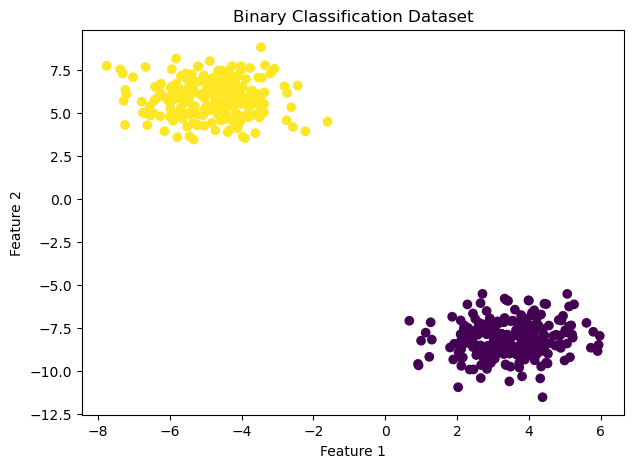

In [55]:
plt.figure(figsize=(7,5))

# YOUR CODE HERE
plt.scatter(X[:,0], X[:,1], c = y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Binary Classification Dataset")
plt.show()

## 4. Logistic Regression Model

The model first calculates

$$
z = Xw+b
$$

and then

$$
\hat y = \sigma(z)
$$

where

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

If `X.shape = (m,n)` and `w.shape = (n,)`, then `X @ w` has shape `(m,)`.

## 5. Step 1 — Implement Sigmoid

### Task
Complete `sigmoid(z)`.

Use `np.exp()`. Your function should work for both a scalar and a NumPy array.

In [56]:
def sigmoid(z):
    # YOUR CODE HERE
    return (1/ (1+np.exp(-z)))

In [57]:
test_values = np.array([-10, -2, 0, 2, 10])
print(sigmoid(test_values))

# Remember: sigmoid(0) should be 0.5

[4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


## 6. Step 2 — Compute the Linear Score

Implement

`z = X @ w + b`

### Hint
Use the `@` operator for matrix-vector multiplication.

In [58]:
def compute_z(X, w, b):
    # YOUR CODE HERE
    return (X @ w) + b

In [60]:
w = np.zeros(X.shape[1])
b = 0.0

z = compute_z(X, w, b)

print("z:", z)
print("z shape:", z.shape)

z: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

## 7. Step 3 — Compute Predicted Probabilities

The predicted probability is

$$
\hat y = \sigma(Xw+b)
$$

### Task
Implement `predict_probability()` using the functions you have already written.

In [61]:
def predict_probability(X, w, b):
    # YOUR CODE HERE
    return sigmoid((X @ w) + b)

In [62]:
probabilities = predict_probability(X, w, b)
print(probabilities)

[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5
 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.

## 8. Step 4 — Implement the Cost Function

For binary Logistic Regression,

$$
J =
-\frac{1}{m}\sum_{i=1}^{m}
\left[
y^{(i)}\log(\hat y^{(i)})
+
(1-y^{(i)})\log(1-\hat y^{(i)})
\right]
$$

Use `np.clip()` to avoid taking `log(0)`.

### Hint
```python
epsilon = 1e-15
probabilities = np.clip(probabilities, epsilon, 1-epsilon)
```

In [63]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    epsilon = 1e-15
    probabilities = np.clip(sigmoid((X @ w) + b), epsilon, 1-epsilon)
    # YOUR CODE HERE
    cost = -(1/m)* (np.sum((y * np.log(probabilities)) + ((1 - y)*np.log(1 - probabilities))))
    return cost

In [64]:
initial_cost = compute_cost(X, y, w, b)
print("Initial cost:", initial_cost)

# With w=0 and b=0, every probability is 0.5.

Initial cost: 0.6931471805599454


## 9. Step 5 — Compute the Gradients

The gradients are

$$
dw = \frac{1}{m}X^T(\hat y-y)
$$

$$
db = \frac{1}{m}\sum(\hat y-y)
$$

### Shape check

If

```text
X.shape = (m,n)
w.shape = (n,)
y.shape = (m,)
```

then

```text
X.T.shape = (n,m)
y_hat-y   = (m,)
dw        = (n,)
```

Do not use a loop over training examples. Rather, use broadcasting.

In [65]:
def compute_gradients(X, y, w, b):
    m = X.shape[0]

    # YOUR CODE HERE
    dw = (1/m) * X.T @ (sigmoid((X @ w) + b) - y)
    db = (1/m) * np.sum(sigmoid((X @ w) + b) - y)
    return dw, db

In [66]:
dw, db = compute_gradients(X, y, w, b)

print("dw:", dw)
print("dw shape:", dw.shape)
print("db:", db)

dw: [ 2.06738031 -3.51061819]
dw shape: (2,)
db: 0.0


## 10. Step 6 — Implement One Gradient-Descent Update

Use

$$
w := w - \alpha dw
$$

$$
b := b - \alpha db
$$

### Task
Compute the gradients, update `w` and `b`, and return them.

In [67]:
def gradient_descent_step(X, y, w, b, learning_rate):
    # YOUR CODE HERE
    m = X.shape[0]
    w = w - learning_rate * ((1/m) * X.T @ (sigmoid((X @ w) + b) - y))
    b = b - learning_rate * ((1/m) * np.sum(sigmoid((X @ w) + b) - y))
    return w, b

## 11. Step 7 — Implement Complete Gradient Descent

For each iteration:
1. Compute probabilities.
2. Compute cost.
3. Compute gradients.
4. Update parameters.
5. Store the cost.

In [68]:
def train_logistic_regression(X, y, learning_rate=0.1, num_iterations=1000):

    w = np.zeros(X.shape[1])
    b = 0.0

    cost_history = []

    for i in range(num_iterations):

        # YOUR CODE HERE
        probabilities = predict_probability(X, w, b)
        cost = compute_cost(X, y, w, b)
        w, b = gradient_descent_step(X, y, w, b, learning_rate)
        cost_history.append(cost)

    return w, b, cost_history

## 12. Train the Model

Use learning rate `0.1` and `1000` iterations.

In [69]:
learning_rate = 0.1
num_iterations = 1000

w, b, cost_history = train_logistic_regression(
    X, y, learning_rate, num_iterations
)

print("Final weights:", w)
print("Final bias:", b)
print("Final cost:", cost_history[-1])

Final weights: [-0.62136375  0.96086514]
Final bias: 0.04528928492016605
Final cost: 0.00021720695950262195


## 13. Plot the Cost

Plot iteration number against cost.

### Expected observation
The cost should generally decrease during training.

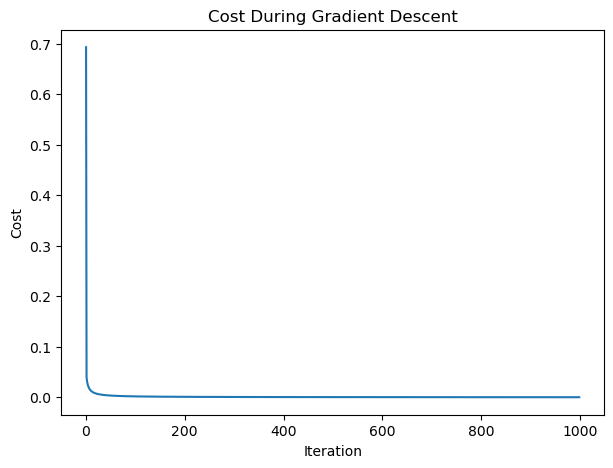

In [70]:
plt.figure(figsize=(7,5))

# YOUR CODE HERE
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Gradient Descent")
plt.show()

## 14. Step 8 — Convert Probabilities into Class Predictions

Use the rule

$$
\hat y =
\begin{cases}
1 & \text{if probability} \geq 0.5\\
0 & \text{otherwise}
\end{cases}
$$

### Hint
```python
(probabilities >= threshold).astype(int)
```

In [71]:
def predict(X, w, b, threshold=0.5):
    # YOUR CODE HERE
    probabilities = predict_probability(X, w, b)
    return np.array((probabilities >= threshold).astype(int))

In [72]:
y_pred = predict(X, w, b)

print("Predictions:", y_pred)
print("Actual:     ", y)

Predictions: [1 0 1 1 0 1 0 0 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 1 1 1 0 1 0 0 0 0 1 0 1 0 1
 0 1 1 0 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 1 0 1 0 1 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 0 1 0 0 1 0 0 1 1
 1 1 0 0 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 1 0 0 1
 0 1 0 1 0 1 1 1 1 0 1 0 1 0 0 1 1 0 1 1 0 0 1 1 1 0 1 0 0 0 1 0 1 0 0 1 0
 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 1 1 0 1 1 0 1 0 0 0 1 1 1 0 0 0
 1 0 1 1 1 0 1 1 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 1 1 0 0 0 1 1 0 0 1 1 1 0 1
 0 0 1 1 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 0 1 1 1 1 0 1 1 1 1
 1 1 1 1 0 1 1 1 1 0 0 1 1 1 0 1 0 0 0 1 1 1 0 1 0 0 1 1 1 0 1 0 1 0 1 0 0
 0 1 1 1 0 0 1 0 1 0 0 0 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 1 1 1 0 1 0 0 0 0 0 1 1
 0 0 0 1 0 0 1 1 1 0 1 0 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 1 0 1 1 1 0 1 0 0 1
 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 1 0 0 0 0 1 1 1 1 0 0 1 1 0 0 1 1 0 1 0 0 0
 1 0 1 0 0 0

## 15. Step 9 — Calculate Accuracy

$$
Accuracy =
\frac{\text{Number of correct predictions}}
{\text{Total number of predictions}}
$$

### Task
Implement `accuracy()` using NumPy.

In [73]:
def accuracy(y_true, y_pred):
    # YOUR CODE HERE
    return np.mean(y_true == y_pred)

In [74]:
print("Accuracy:", accuracy(y, y_pred))

Accuracy: 1.0


## 16. Step 10 — Visualize the Decision Boundary

For two features, the decision boundary is

$$
w_1x_1+w_2x_2+b=0
$$

Therefore,

$$
x_2=-\frac{w_1x_1+b}{w_2}
$$

### Task
Plot the two classes and the learned decision boundary.

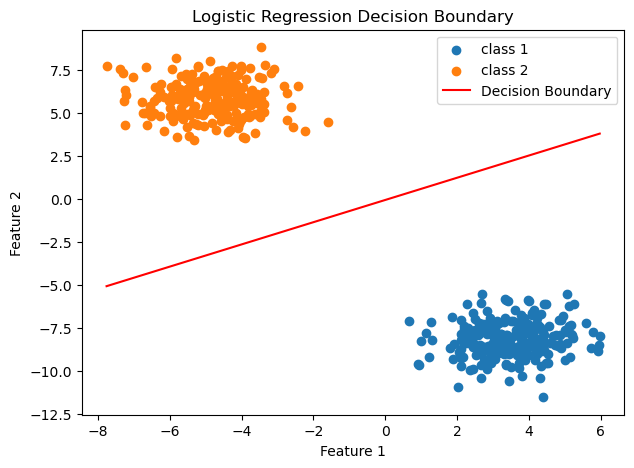

In [75]:
x_values = np.array([np.min(X[:, 0]), np.max(X[:, 0])])
y_values = -(w[0] * x_values + b) / w[1]

plt.figure(figsize=(7,5))

# YOUR CODE HERE
plt.scatter(X[y==0, 0], X[y==0, 1], label = 'class 1')
plt.scatter(X[y==1, 0], X[y==1, 1], label = 'class 2')
plt.plot(x_values, y_values, color='red', label='Decision Boundary')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Test your understanding — Learning Rate Experiment

Train the model using:

- `0.001`
- `0.1`
- `1.0`

Record the final cost and accuracy.

### Question
Which learning rate appears most appropriate for this dataset, and why?

In [76]:
learning_rates = [0.001, 0.1, 1.0]

final_costs = np.array([])
acc = np.array([])
for i in range(len(learning_rates)):
    w, b, cost_history = train_logistic_regression(X, y, learning_rates[i], num_iterations = 1000)
    final_costs = np.append(final_costs, cost_history[-1])
    y_pred = predict(X, w, b)
    acc = np.append(acc, accuracy(y, y_pred))
    
print(final_costs, acc)

[1.80220872e-02 2.17206960e-04 4.04464805e-11] [1. 1. 1.]


# Test your understanding — Classification Threshold

Use thresholds:

- `0.3`
- `0.5`
- `0.7`

Compare the predictions and accuracy.

### Question
Why can changing the threshold change the classification result without changing the learned weights?

In [77]:
thresholds = [0.3, 0.5, 0.7]
acc = np.array([])
# YOUR CODE HERE
for i in range(len(thresholds)):
    y_pred = predict(X, w, b, threshold = thresholds[i])
    acc = np.append(acc, accuracy(y, y_pred))

print(acc)

[1. 1. 1.]


**Important:** Use vectorized NumPy operations wherever possible instead of loops.

In [53]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 2)